In [1]:
import sys
import os

# Agrega el directorio anterior al sys.path
sys.path.append(os.path.abspath(".."))


import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import my_module as mm
from scipy import stats
import importlib
import scipy.linalg as la
from getdist import MCSamples, plots
from scipy.constants import c

#Refresh the changes made on my_module files
importlib.reload(mm)


#Matplotlib parameters

plt.rcParams.update({
    # Font
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],  # Or your preferred from the list
    "font.size": 14,                 # Base font size for all text

    # Axes labels & title sizes
    "axes.titlesize": 16,
    "axes.labelsize": 14,

    # Tick parameters
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

})

plt.rcParams['text.usetex'] = True

In [2]:
#Pantheon+ data import
data_Pan, cov_Pan = mm.data_import.Pantheon_data(cut=False)

#DES data import
data_DES, cov_DES = mm.data_import.DES_data(cut=False)

#Sort data by redshift
data_DES = data_DES.sort_values(by='zHD')
data_Pan = data_Pan.sort_values(by='zHD')

In [3]:
text_folder = '../../text/images/'

In [4]:
#Define parameter names and labels
param_names = ['om_m', 'H0']  
labels = [r'\Omega_m', r'H_0']

#data import from MCMC chains
data_Pan_T1 = np.loadtxt("samples_Pan_0.0_0.75461.txt")
data_Pan_T2 = np.loadtxt("samples_Pan_0.75461_1.508.txt")
data_Pan_T3 = np.loadtxt("samples_Pan_1.508_3.0.txt")


data_Pan_C1 = np.loadtxt("samples_Pan_0.0_0.03705.txt")
data_Pan_C2 = np.loadtxt("samples_Pan_0.03705_0.2664.txt")
data_Pan_C3 = np.loadtxt("samples_Pan_0.2664_3.0.txt")


data_DES_T1 = np.loadtxt("samples_DES_0.0_0.3905.txt")
data_DES_T2 = np.loadtxt("samples_DES_0.3905_0.756.txt")
data_DES_T3 = np.loadtxt("samples_DES_0.756_3.0.txt")


data_DES_C1 = np.loadtxt("samples_DES_0.0_0.3678.txt")
data_DES_C2 = np.loadtxt("samples_DES_0.3678_0.5808.txt")
data_DES_C3 = np.loadtxt("samples_DES_0.5808_3.0.txt")

#Convert it into MCSamples object
samples_Pan_T1 = MCSamples(samples=data_Pan_T1, names=param_names, labels=labels)
samples_Pan_T2 = MCSamples(samples=data_Pan_T2, names=param_names, labels=labels)
samples_Pan_T3 = MCSamples(samples=data_Pan_T3, names=param_names, labels=labels)

samples_Pan_C1 = MCSamples(samples=data_Pan_C1, names=param_names, labels=labels)
samples_Pan_C2 = MCSamples(samples=data_Pan_C2, names=param_names, labels=labels)
samples_Pan_C3 = MCSamples(samples=data_Pan_C3, names=param_names, labels=labels)

samples_DES_T1 = MCSamples(samples=data_DES_T1, names=param_names, labels=labels)
samples_DES_T2 = MCSamples(samples=data_DES_T2, names=param_names, labels=labels)
samples_DES_T3 = MCSamples(samples=data_DES_T3, names=param_names, labels=labels)

samples_DES_C1 = MCSamples(samples=data_DES_C1, names=param_names, labels=labels)
samples_DES_C2 = MCSamples(samples=data_DES_C2, names=param_names, labels=labels)
samples_DES_C3 = MCSamples(samples=data_DES_C3, names=param_names, labels=labels)

# Function to summarize MCSamples
def summarize_mc_samples(mc_sample, sample_name):
    """
    Print mean ± standard deviation for each parameter in an MCSamples object.
    
    Parameters
    ----------
    mc_sample : MCSamples
        MCSamples object containing the MCMC samples.
    """
    param_names = mc_sample.getParamNames().names
    for name in param_names:
        mean = mc_sample.mean(name)
        err = mc_sample.std(name)
        print(f"{sample_name} - {name}: {mean:.4f} ± {err:.4f}")

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


g3 - om_m	\Omega_m: 0.5169 ± 0.2586
g3 - H0	H_0: 68.9954 ± 12.1948
g2 - om_m	\Omega_m: 0.4403 ± 0.2480
g2 - H0	H_0: 70.5728 ± 8.2627
g1 - om_m	\Omega_m: 0.3848 ± 0.0477
g1 - H0	H_0: 72.5108 ± 0.5787


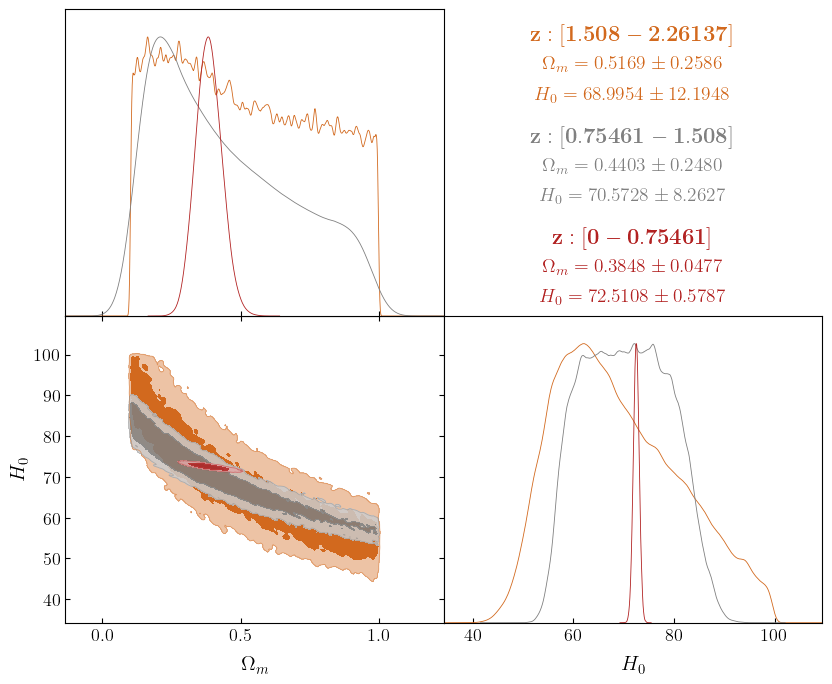

In [5]:
mm.make_triangle_plot(
    [samples_Pan_T3, samples_Pan_T2, samples_Pan_T1],
    labels = labels,
    colors=['chocolate', 'gray', 'firebrick'],
    outfile=text_folder + 'Pan_binning_size.png',
    figsize=(10, 8),
    dpi=300,
    dataset_names=['z:[1.508 - 2.26137]', 'z:[0.75461 - 1.508]', 'z:[0 - 0.75461]'])

summarize_mc_samples(samples_Pan_T3, sample_name='g3')
summarize_mc_samples(samples_Pan_T2, sample_name='g2')
summarize_mc_samples(samples_Pan_T1, sample_name='g1')

g2 - om_m	\Omega_m: 0.3723 ± 0.1442
g2 - H0	H_0: 72.8029 ± 1.2352
g3 - om_m	\Omega_m: 0.3766 ± 0.0886
g3 - H0	H_0: 72.2928 ± 1.9728
g1 - om_m	\Omega_m: 0.5973 ± 0.2545
g1 - H0	H_0: 72.1350 ± 0.7779


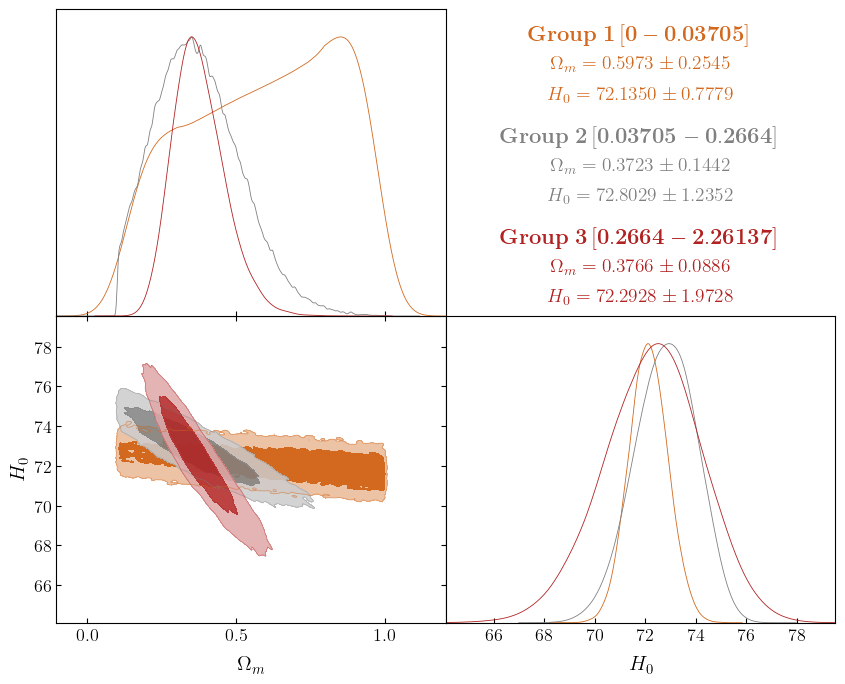

In [6]:
mm.make_triangle_plot(
    [samples_Pan_C1, samples_Pan_C2, samples_Pan_C3],
    labels = labels,
    colors=['chocolate', 'gray', 'firebrick'],
    outfile=text_folder + 'Pan_binning_count.png',
    figsize=(10, 8),
    dpi=300,
    dataset_names=['Group \; 1 \, [0 - 0.03705]', 'Group \; 2 \, [0.03705 - 0.2664]', 'Group \; 3 \, [0.2664 - 2.26137]'] )

summarize_mc_samples(samples_Pan_C2, sample_name='g2')
summarize_mc_samples(samples_Pan_C3, sample_name='g3')  
summarize_mc_samples(samples_Pan_C1, sample_name='g1')  



g2 - om_m	\Omega_m: 0.1002 ± 0.0002
g2 - H0	H_0: 10.0003 ± 0.0003
g3 - om_m	\Omega_m: 0.9997 ± 0.0003
g3 - H0	H_0: 99.9893 ± 0.0106
g1 - om_m	\Omega_m: 0.3505 ± 0.0485
g1 - H0	H_0: 69.7297 ± 0.6808


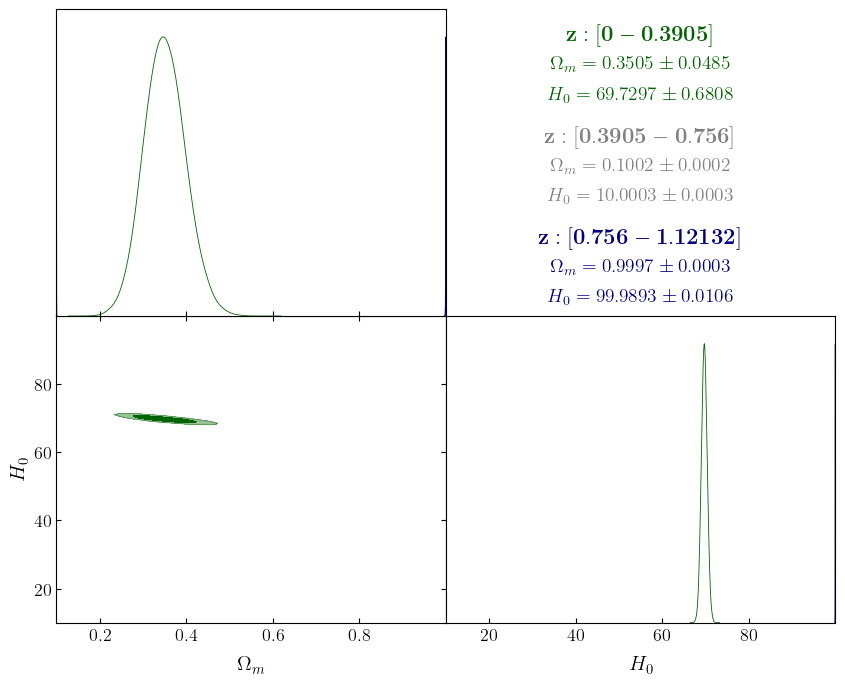

In [7]:
mm.make_triangle_plot(
    [samples_DES_T1, samples_DES_T2, samples_DES_T3],
    labels = labels,
    colors=['darkgreen', 'gray', 'navy'],
    outfile=text_folder + 'DES_binning_size.png',
    figsize=(10, 8),
    dpi=300,
    dataset_names=['z:[0 - 0.3905]', 'z:[0.3905 - 0.756]', 'z:[0.756 - 1.12132]'] )

summarize_mc_samples(samples_DES_T2, sample_name='g2')
summarize_mc_samples(samples_DES_T3, sample_name='g3')  
summarize_mc_samples(samples_DES_T1, sample_name='g1')  


g2 - om_m	\Omega_m: 0.1563 ± 0.0133
g2 - H0	H_0: 17.7652 ± 0.1906
g3 - om_m	\Omega_m: 0.3711 ± 0.0089
g3 - H0	H_0: 10.0006 ± 0.0006
g1 - om_m	\Omega_m: 0.3295 ± 0.0495
g1 - H0	H_0: 69.9620 ± 0.6778


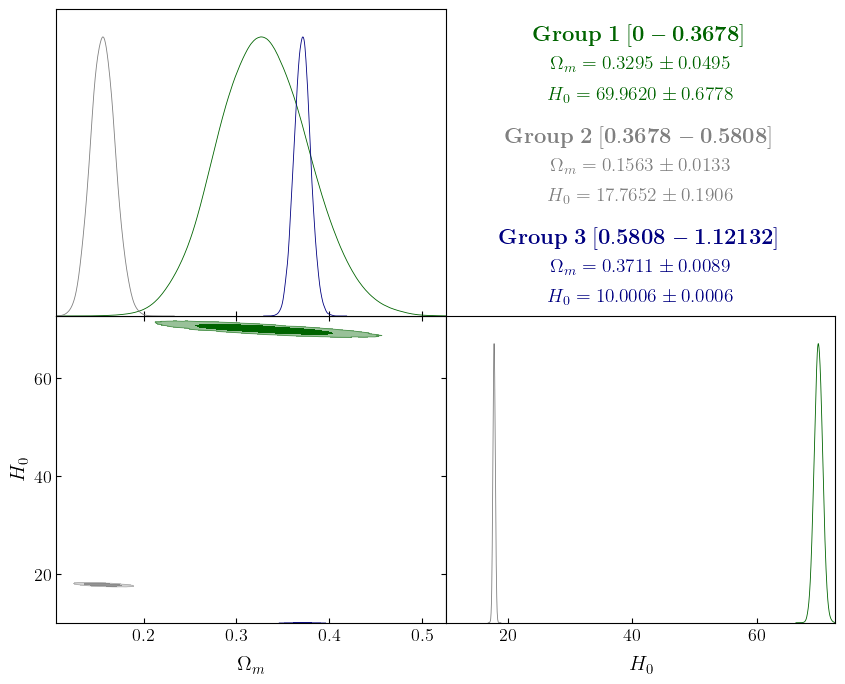

In [8]:
mm.make_triangle_plot(
    [samples_DES_C1, samples_DES_C2, samples_DES_C3],
    labels = labels,
    colors=['darkgreen', 'gray', 'navy'],
    outfile=text_folder + 'DES_binning_count.png',
    figsize=(10, 8),
    dpi=300,
    dataset_names=['Group \; 1 \; [0 - 0.3678]', 'Group \; 2 \; [0.3678 - 0.5808]', 'Group \; 3 \; [0.5808 - 1.12132]'] )

summarize_mc_samples(samples_DES_C2, sample_name='g2')
summarize_mc_samples(samples_DES_C3, sample_name='g3')  
summarize_mc_samples(samples_DES_C1, sample_name='g1')  